In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs

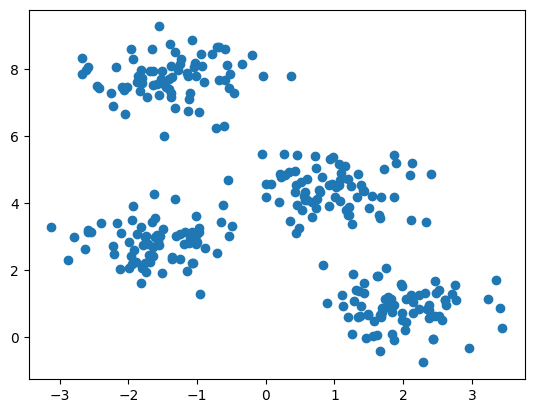

In [61]:
# create dataset
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['x1', 'x2'])
plt.scatter(df.iloc[:,0], df.iloc[:,1])

## K-means steps


1.   define k
2.   randomly place k centroids
3.   assign each point to a cluster( the cluster of the closest centroid)
4.   update the centroids(the new centroid is the mean of the cluster)
5.   repeat from step 3
6.   stop when the centroids no longer change
<img src="https://files.realpython.com/media/centroids_iterations.247379590275.gif" width="750" align="center">

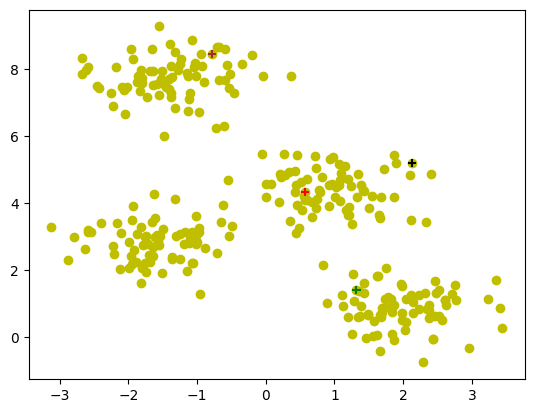

In [62]:
# 1. define k
k = 4

# 2. randomly place k centroids
centroids = df.sample(k).values
plt.scatter(df['x1'], df['x2'], c = 'y')
plt.scatter(centroids[:,0], centroids[:,1], color = ['r', 'g', 'black', 'brown'], marker  = '+')

In [63]:
# 4. update the centroids(the new centroid is the mean of the cluster)
for i in range(len(centroids)):
    centroids[i][0] = np.mean(df[df['closest'] == i]['x1'])
    centroids[i][1] = np.mean(df[df['closest'] == i]['x2'])

KeyError: 'closest'

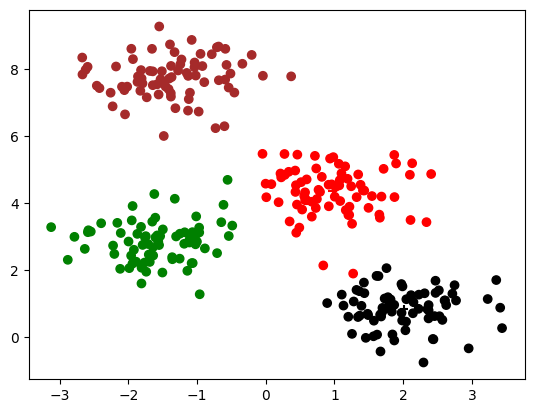

In [ ]:
plt.scatter(df['x1'], df['x2'], c = df['color'])
plt.scatter(centroids[:,0], centroids[:,1], color = ['r', 'g', 'black', 'brown'], marker  = '+');

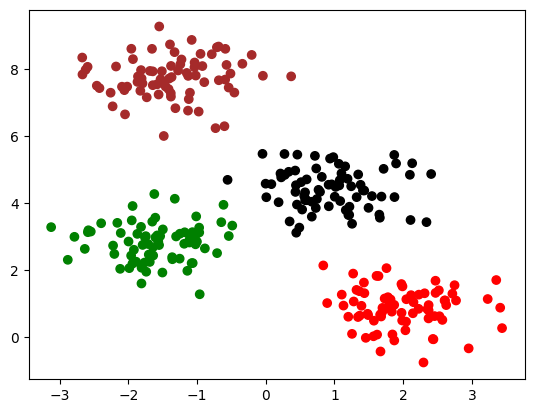

In [ ]:
# 1. define k
k = 4

# 2. randomly place k centroids
centroids = df.sample(k).values

for i in range(50):
    # 3. assign each point to a cluster( the cluster of the closest centroid)
    for i in range(k):
        df[i] = np.sqrt((df['x1'] - centroids[i][0]) ** 2  + (df['x2'] - centroids[i][1]) ** 2)

    colors = {0: 'red', 1:'green', 2: 'black', 3:'brown' }
    df['closest'] = df.loc[:, [0,1,2,3]].idxmin(axis=1)
    df['color'] = df['closest'].map(lambda x: colors[x])
    old  = centroids.copy
    # 4. update the centroids(the new centroid is the mean of the cluster)
    for i in range(len(centroids)):
        centroids[i][0] = np.mean(df[df['closest'] == i]['x1'])
        centroids[i][1] = np.mean(df[df['closest'] == i]['x2'])

    if np.all(old == centroids):
        break
    # 5. repeat from step 3

plt.scatter(df['x1'], df['x2'], c = df['color']);

## [Complete] Use elbow method to determine the best number of clusters

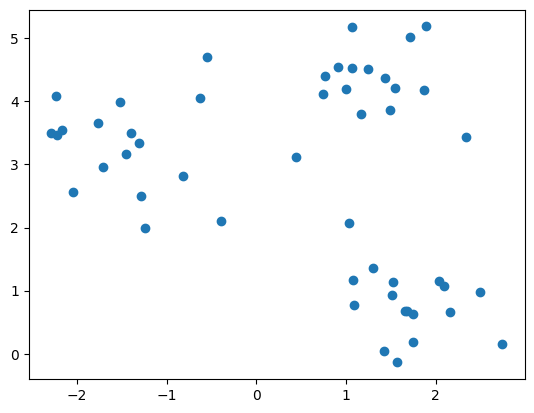

In [65]:

X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['x1', 'x2'])
plt.scatter(df.iloc[:,0], df.iloc[:,1])

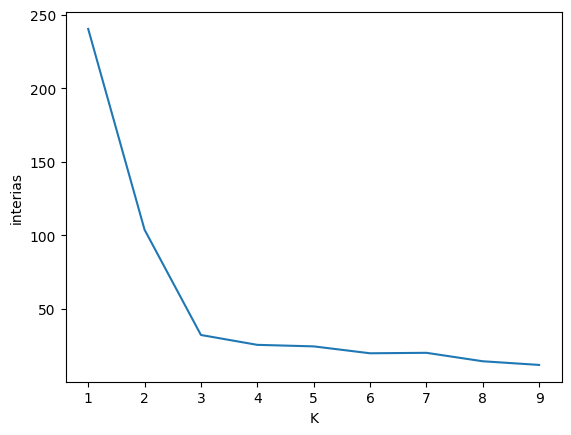

In [66]:
from sklearn.cluster import KMeans 
from sklearn import metrics 
from scipy.spatial.distance import cdist 
import numpy as np 
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

x = df.iloc[:,:2]
inertias = [] 
mapping = {} 
K = range(1,10)
# Complete the code
for k in K: 
    kmeanModel = KMeans(n_clusters=k).fit(x) 
    inertias.append(kmeanModel.inertia_) 
    mapping[k] = kmeanModel.inertia_

plt.plot(K , inertias)
plt.xlabel("K")
plt.ylabel("interias")

plt.show()

In [67]:
mapping

{1: 240.28365165523175,
 2: 103.69241848201798,
 3: 32.096807413180294,
 4: 25.381456400718754,
 5: 24.344017476695466,
 6: 19.648958438733185,
 7: 19.963065166779085,
 8: 14.216324337802048,
 9: 11.727018528001716}

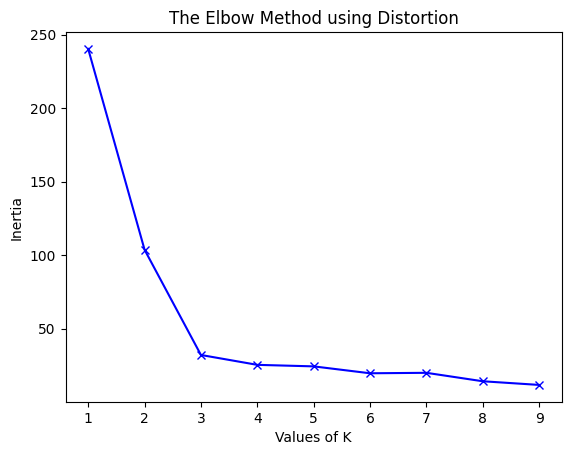

In [68]:
plt.plot(K, inertias, 'bx-') 
plt.xlabel('Values of K') 
plt.ylabel('Inertia') 
plt.title('The Elbow Method using Distortion') 
plt.show() 

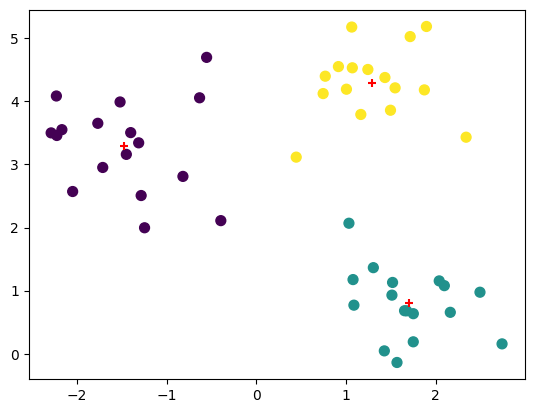

In [70]:
kmeanModel = KMeans(n_clusters=3).fit(x)
y_kmeans = kmeanModel.predict(x)

plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y_kmeans, s=50)
centers = kmeanModel.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='+', c= 'red')
